# 8 · The JAX backend and automatic differentiation

The `jax` backend builds the Gibbs state in JAX and obtains **gradients and quantum
Fisher information by automatic differentiation** of the state construction
(`jax.grad` / `jax.jacrev`) — not from the hand-derived analytic formulas.

Two payoffs:

1. **Independent verification.** If autodiff (differentiating numerically through
   `eigh`) reproduces the analytic belief-propagation gradient and the
   Kubo–Mori / Fisher–Bures / Wigner–Yanase metrics, both are correct.
2. **Novel losses for free.** Any objective you can write as a function of the
   density matrix can be trained without deriving its gradient by hand.

Requires `pip install qbmkit[jax]` (and NumPy ≥ 2).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm
from qbm.operators import ParamHamiltonian, local_pauli_generators

print("available backends:", qbm.available_backends())
ham = ParamHamiltonian(local_pauli_generators(3))
theta = np.random.default_rng(0).normal(scale=0.5, size=ham.n_params)
dense = qbm.DenseBackend().thermal_state(ham, theta)
jx = qbm.get_backend("jax").thermal_state(ham, theta)

available backends: ['dense', 'jax', 'statevector']


### Autodiff reproduces the analytic gradient and metrics

We compare, component by component, the analytic (dense) and autodiff (JAX)
results for the energy gradient and the three QFI metrics.

max |grad_analytic - grad_autodiff| = 3.3306690738754696e-16


max |metric[kubo_mori] analytic - autodiff| = 1.55e-15
max |metric[fisher_bures] analytic - autodiff| = 1.11e-15
max |metric[wigner_yanase] analytic - autodiff| = 2.00e-15


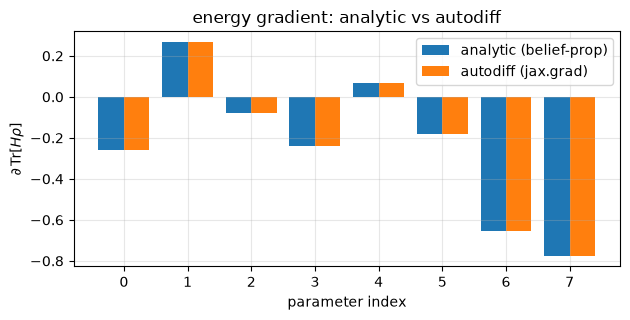

In [2]:
O = qbm.hamiltonians.heisenberg(3)
g_analytic = dense.observable_gradient(O)
g_autodiff = jx.observable_gradient(O)

print("max |grad_analytic - grad_autodiff| =", np.max(np.abs(g_analytic - g_autodiff)))
for kind in ("kubo_mori", "fisher_bures", "wigner_yanase"):
    diff = np.max(np.abs(dense.metric(kind) - jx.metric(kind)))
    print(f"max |metric[{kind}] analytic - autodiff| = {diff:.2e}")

fig, ax = plt.subplots(figsize=(6.4, 3.3))
idx = np.arange(len(g_analytic)); w = 0.4
ax.bar(idx - w/2, g_analytic, width=w, label="analytic (belief-prop)")
ax.bar(idx + w/2, g_autodiff, width=w, label="autodiff (jax.grad)")
ax.set_xlabel("parameter index"); ax.set_ylabel(r"$\partial\,\mathrm{Tr}[H\rho]$")
ax.set_title("energy gradient: analytic vs autodiff"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### A novel loss with no hand-derived gradient

Suppose we want the model to **match chosen expectation values** — a custom
moment-matching objective $L = (\langle Z_0\rangle - t_1)^2 + (\langle X_1\rangle - t_2)^2$.
There is no built-in gradient for this, but `qbm.autodiff` differentiates it
automatically; we wrap it as an ordinary `Loss` and train with the standard loop.

<Z0> = 0.500 (target 0.5)
<X1> = -0.300 (target -0.3)


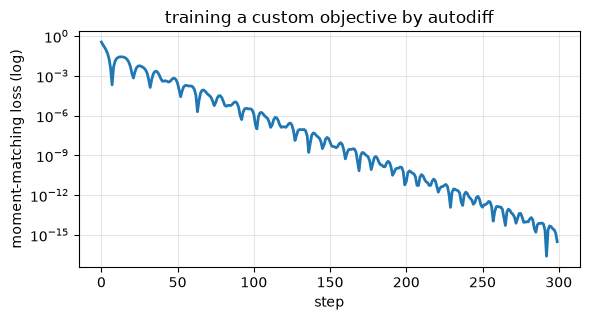

final loss = 3.11e-16


In [3]:
import jax.numpy as jnp
from qbm import autodiff

class MomentMatch(qbm.losses.Loss):
    def __init__(self, targets, generators):
        # targets: list of (operator, value)
        self.gens = generators
        self.ops = [(jnp.asarray(np.asarray(O, complex)), float(t)) for O, t in targets]
    def _value_fn(self, rho):
        return sum((jnp.real(jnp.trace(O @ rho)) - t) ** 2 for O, t in self.ops)
    def value(self, state):
        return autodiff.value_and_grad(self.gens, state.theta, self._value_fn)[0]
    def grad(self, state):
        return autodiff.value_and_grad(self.gens, state.theta, self._value_fn)[1]

targets = [(qbm.pauli("ZII"), 0.5), (qbm.pauli("IXI"), -0.3)]
model = qbm.FullyVisibleQBM(n=3)
model.theta = np.random.default_rng(1).normal(scale=0.2, size=model.n_params)
hist = qbm.fit(model, MomentMatch(targets, model.ham.generators),
               qbm.optim.Adam(lr=0.1), steps=300)

st = model.state()
print(f"<Z0> = {st.expect(qbm.pauli('ZII')):.3f} (target 0.5)")
print(f"<X1> = {st.expect(qbm.pauli('IXI')):.3f} (target -0.3)")

plt.figure(figsize=(6, 3.3))
plt.semilogy(np.clip(hist.loss, 1e-17, None), lw=2)
plt.xlabel("step"); plt.ylabel("moment-matching loss (log)")
plt.title("training a custom objective by autodiff"); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print("final loss =", f"{hist.final_loss:.2e}")

### Recap

- The JAX backend computes gradients/metrics by autodiff and matches the analytic
  engine to ~1e-7 — an independent proof of the hand-derived formulas.
- `qbm.autodiff` lets you train arbitrary density-matrix objectives without
  deriving gradients, and the JAX backend runs on GPU/TPU.
- Same models, losses, optimizers, and training loop as every other backend.